# Accident Severity Prediction using Machine Learning
### Predicting Road Accident Severity from Pre-Crash Environmental and Situational Signals

---

**Objective:** Predict the severity of a road accident using pre-crash conditions such as weather, visibility, road features, and time of day before the accident occurs.

**Why This Matters:**
Road accidents cause millions of injuries and fatalities every year. Most existing research analyzes accidents after they happen. This project asks a different question: can we predict how severe an accident will be before or at the moment of impact, using signals that are already present in the environment? If yes, autonomous vehicles and smart traffic systems can act on those signals in real time.

**Dataset:** US Accidents dataset by Sobhan Moosavi (Kaggle)
7.7 million real US road accident records from 2016 to 2023, covering 49 US states.

**Pipeline Overview:**
1. Install and import libraries
2. Load dataset using Kaggle API
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Class Imbalance Handling
7. Model Training and Comparison
8. Model Evaluation
9. SHAP Explainability
10. Conclusion

## Phase 1 - Install Required Libraries

We install all libraries needed for data processing, machine learning, visualization, and explainability.

| Library | Purpose |
|---|---|
| pandas, numpy | Data manipulation |
| scikit-learn | ML models and preprocessing |
| xgboost | Gradient boosting model |
| shap | Model explainability |
| matplotlib, seaborn | Visualization |
| imbalanced-learn | Handle class imbalance with SMOTE |

In [1]:
!pip install pandas numpy scikit-learn xgboost shap imbalanced-learn matplotlib seaborn --quiet
print('All libraries installed successfully.')

All libraries installed successfully.


## Phase 2 - Import Libraries and Configuration

Import all required libraries and configure display settings. A fixed random seed ensures reproducibility across all experiments.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported. Ready to go.')

Libraries imported. Ready to go.


## Phase 3 - Load Dataset using Kaggle API

We use the US Accidents dataset by Sobhan Moosavi. It contains 7.7 million real road accident records from 2016 to 2023 across 49 US states with 46 features including weather conditions, road features, time of day, and accident severity.

**Severity scale:**
- 1 = Minimal impact on traffic
- 2 = Minor impact
- 3 = Moderate impact
- 4 = Significant impact on traffic flow

**Steps to get the dataset:**
1. Go to kaggle.com and sign in
2. Click your profile picture at the top right and go to Settings
3. Scroll down to API and click Create New Token. This downloads kaggle.json
4. Run the upload cell below and select your kaggle.json file
5. Then run the download cell to pull the dataset directly into Colab

In [3]:
# Step 1: Upload your kaggle.json token
from google.colab import files
files.upload()  # Select your kaggle.json file here

# Step 2: Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 3: Download the dataset
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip -q us-accidents.zip

print('Dataset downloaded.')
print(os.listdir())

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:04<00:00, 154MB/s]

Dataset downloaded.
['.config', 'kaggle.json', 'US_Accidents_March23.csv', 'us-accidents.zip', 'sample_data']


## Phase 4 - Load and Inspect Data

The full dataset has 7.7 million records which is too large to load all at once in Google Colab. We load a sample of 500,000 records for exploratory analysis and modeling. This is still a large and representative sample that gives us statistically meaningful results.

We then inspect the shape, column names, data types, and class distribution to understand what we are working with.

In [4]:
# Load 500,000 rows as a representative sample
df = pd.read_csv('US_Accidents_March23.csv', nrows=500000)

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nSeverity distribution:')
print(df['Severity'].value_counts())
print(f'\nMissing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))
df.head()

Dataset shape: (500000, 46)

Columns: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Severity distribution:
Severity
2    312159
3    187173
1       388
4       280
Name: count, dtype: int64

Missing values (top 10):
End_Lng              500000
End_Lat              500000
Precipitation(in)    448054
Wind_Chill(F)        437641
Wind_Speed(mph)       89040
Visibility(mi)        10539
Weather_Con

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


## Phase 5 - Exploratory Data Analysis

Before modeling we explore the data to understand:
- How accident severity is distributed across the dataset
- Which environmental and situational conditions are most common in severe accidents
- Patterns in time of day, weather, and road features

This helps us choose the right features and understand the problem before building any model.

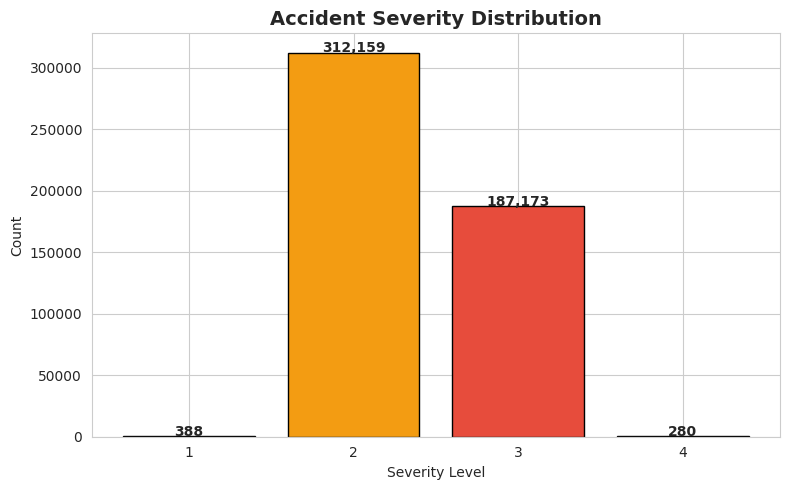

<Figure size 1200x500 with 0 Axes>

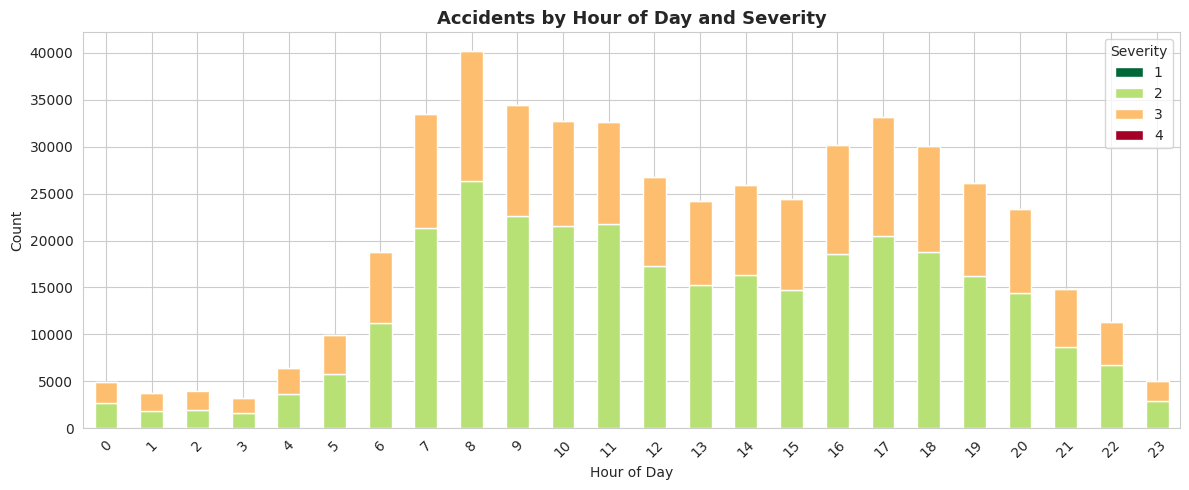

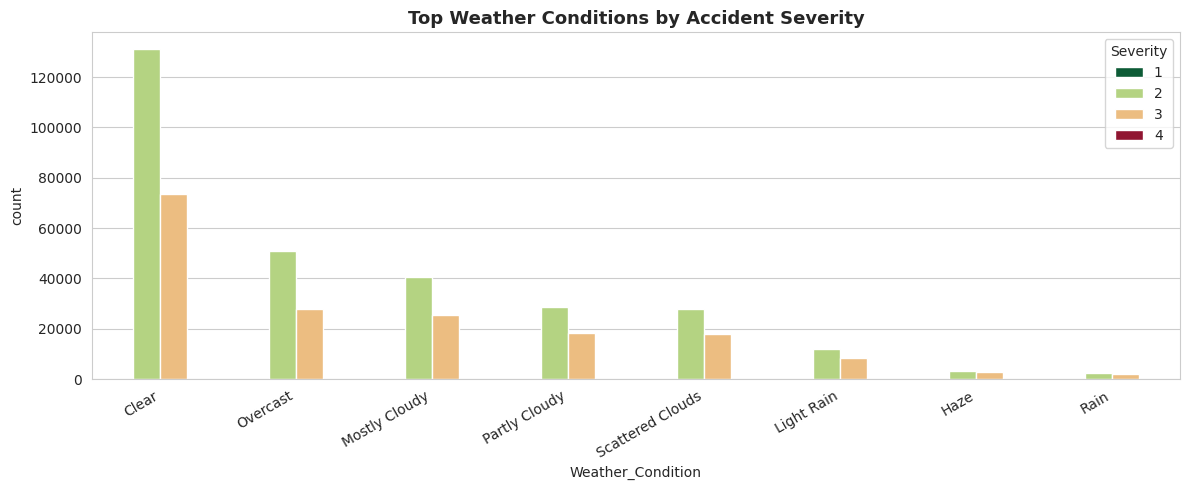

EDA complete.


In [5]:
# Severity distribution
plt.figure(figsize=(8, 5))
counts = df['Severity'].value_counts().sort_index()
bars   = plt.bar(counts.index.astype(str), counts.values,
                 color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}', ha='center', fontweight='bold')
plt.title('Accident Severity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Accidents by hour of day
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['hour']       = df['Start_Time'].dt.hour

plt.figure(figsize=(12, 5))
hour_counts = df.groupby(['hour', 'Severity']).size().unstack(fill_value=0)
hour_counts.plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(12, 5))
plt.title('Accidents by Hour of Day and Severity', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weather condition vs severity
top_weather = df['Weather_Condition'].value_counts().head(8).index
weather_df  = df[df['Weather_Condition'].isin(top_weather)]
plt.figure(figsize=(12, 5))
sns.countplot(data=weather_df, x='Weather_Condition',
              hue='Severity', palette='RdYlGn_r', order=top_weather)
plt.title('Top Weather Conditions by Accident Severity', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('EDA complete.')

## Phase 6 - Data Preprocessing

We select the pre-crash features that are available before an accident occurs and clean the data for modeling.

**Features selected:**
- Time features: hour, day of week, month, is_night, is_rush_hour
- Weather: temperature, humidity, visibility, wind speed, precipitation
- Road features: junction, traffic signal, crossing, roundabout, stop
- Weather condition type: encoded from text

We drop rows with excessive missing values and fill remaining gaps with median or mode values.

We also simplify the target variable into a binary classification: severity 1-2 as Minor and severity 3-4 as Severe. This makes the problem cleaner and the results more actionable.

In [6]:
# Parse datetime features
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['hour']         = df['Start_Time'].dt.hour
df['day_of_week']  = df['Start_Time'].dt.dayofweek
df['month']        = df['Start_Time'].dt.month
df['is_night']     = ((df['hour'] < 6) | (df['hour'] >= 20)).astype(int)
df['is_rush_hour'] = (((df['hour'] >= 7) & (df['hour'] <= 9)) |
                      ((df['hour'] >= 16) & (df['hour'] <= 19))).astype(int)

# Encode weather condition
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')
weather_encoder = LabelEncoder()
df['weather_encoded'] = weather_encoder.fit_transform(df['Weather_Condition'])

# Binary target: 0 = Minor (Severity 1-2), 1 = Severe (Severity 3-4)
df['severity_binary'] = (df['Severity'] >= 3).astype(int)
print(f'Target distribution:')
print(df['severity_binary'].value_counts())

# Select features
FEATURES = [
    'hour', 'day_of_week', 'month', 'is_night', 'is_rush_hour',
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)',
    'weather_encoded',
    'Junction', 'Traffic_Signal', 'Crossing', 'Roundabout', 'Stop'
]

# Convert boolean columns to int
bool_cols = ['Junction', 'Traffic_Signal', 'Crossing', 'Roundabout', 'Stop']
for col in bool_cols:
    df[col] = df[col].astype(int)

# Drop rows with missing values in selected features
df_clean = df[FEATURES + ['severity_binary']].dropna()

print(f'\nClean dataset shape: {df_clean.shape}')
print(f'Features: {len(FEATURES)}')
df_clean.head()

Target distribution:
severity_binary
0    312547
1    187453
Name: count, dtype: int64

Clean dataset shape: (46233, 17)
Features: 16


,hour,day_of_week,month,is_night,is_rush_hour,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),weather_encoded,Junction,Traffic_Signal,Crossing,Roundabout,Stop,severity_binary
5,7,0,2,0,1,37.9,97.0,7.0,3.5,0.03,32,0,0,0,0,0,1
9,8,0,2,0,1,37.4,100.0,3.0,4.6,0.02,32,0,0,0,0,0,1
11,8,0,2,0,1,37.4,100.0,3.0,4.6,0.02,32,0,0,0,0,0,1
14,8,0,2,0,1,37.4,100.0,3.0,4.6,0.02,32,0,1,0,0,0,0
20,10,0,2,0,0,33.8,100.0,2.0,4.6,0.01,37,0,0,0,0,0,0


## Phase 7 - Feature Engineering

We engineer additional features that better capture accident risk patterns from the raw data.

| New Feature | Formula | What It Captures |
|---|---|---|
| visibility_risk | 1 - (visibility / max visibility) | Lower visibility = higher risk |
| weather_risk_score | humidity + precipitation combined | Wet and slippery conditions |
| road_complexity | sum of junction, signal, crossing, roundabout | How complex the road environment is |
| temp_extreme | how far temperature is from comfortable range | Very hot or cold conditions |
| wind_risk | normalized wind speed | High wind as a hazard factor |

In [7]:
df_feat = df_clean.copy()

# Visibility risk (lower visibility = higher risk)
max_vis = df_feat['Visibility(mi)'].max()
df_feat['visibility_risk'] = 1 - (df_feat['Visibility(mi)'] / (max_vis + 1e-6))

# Combined weather risk score
df_feat['Precipitation(in)'] = df_feat['Precipitation(in)'].fillna(0)
df_feat['weather_risk_score'] = (
    (df_feat['Humidity(%)'] / 100) +
    (df_feat['Precipitation(in)'] / (df_feat['Precipitation(in)'].max() + 1e-6))
) / 2

# Road complexity score
df_feat['road_complexity'] = (
    df_feat['Junction'] +
    df_feat['Traffic_Signal'] +
    df_feat['Crossing'] +
    df_feat['Roundabout']
)

# Temperature extreme (distance from comfortable 65-75F range)
df_feat['temp_extreme'] = np.abs(df_feat['Temperature(F)'] - 70) / 70

# Wind risk
max_wind = df_feat['Wind_Speed(mph)'].max()
df_feat['wind_risk'] = df_feat['Wind_Speed(mph)'] / (max_wind + 1e-6)

# Add new features to FEATURES list
NEW_FEATURES = ['visibility_risk', 'weather_risk_score', 'road_complexity',
                'temp_extreme', 'wind_risk']
FEATURES_ALL = FEATURES + NEW_FEATURES

print(f'Total features: {len(FEATURES_ALL)}')
print(f'New features added: {NEW_FEATURES}')
df_feat[NEW_FEATURES + ['severity_binary']].describe().T

Total features: 21
New features added: ['visibility_risk', 'weather_risk_score', 'road_complexity', 'temp_extreme', 'wind_risk']


,count,mean,std,min,25%,50%,75%,max
visibility_risk,46233.0,0.934247,0.032559,9.523809e-09,0.904762,0.923810,0.961905,1.000000
weather_risk_score,46233.0,0.418174,0.083497,2.000000e-02,0.390000,0.440000,0.468949,0.963583
road_complexity,46233.0,0.419592,0.671544,0.000000e+00,0.000000,0.000000,1.000000,3.000000
temp_extreme,46233.0,0.247573,0.185875,0.000000e+00,0.100000,0.201429,0.342857,0.944286
wind_risk,46233.0,0.215136,0.118728,0.000000e+00,0.129176,0.180401,0.282851,1.000000
severity_binary,46233.0,0.395756,0.489018,0.000000e+00,0.000000,0.000000,1.000000,1.000000


## Phase 8 - Train Test Split and Class Imbalance Handling

We split the data into training and test sets then apply SMOTE to handle class imbalance.

The dataset is heavily imbalanced with far more minor accidents than severe ones. Without handling this the model would simply learn to always predict minor and achieve high accuracy while being useless for detecting severe accidents.

SMOTE creates synthetic samples of the minority class (severe accidents) in the training data only. We never apply SMOTE to the test set to avoid data leakage.

In [8]:
X = df_feat[FEATURES_ALL].fillna(0)
y = df_feat['severity_binary']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Class distribution before SMOTE:')
print(pd.Series(y_train).value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f'\nClass distribution after SMOTE:')
print(pd.Series(y_train_bal).value_counts())
print(f'\nTest set size: {X_test_sc.shape[0]}')

Class distribution before SMOTE:
severity_binary
0    22349
1    14637
Name: count, dtype: int64

Class distribution after SMOTE:
severity_binary
1    22349
0    22349
Name: count, dtype: int64

Test set size: 9247


## Phase 9 - Model Training and Comparison

We train and compare 3 machine learning models:

| Model | Type | Strength |
|---|---|---|
| Logistic Regression | Linear baseline | Fast, interpretable |
| Random Forest | Ensemble bagging | Robust, handles nonlinearity |
| XGBoost | Ensemble boosting | Usually highest accuracy |

We use AUC-ROC as the main evaluation metric. In accident severity prediction we care more about correctly identifying severe accidents than overall accuracy. AUC-ROC measures how well the model distinguishes between severe and minor accidents across all classification thresholds.


Logistic Regression
   AUC-ROC: 0.7022
              precision    recall  f1-score   support

       Minor       0.86      0.43      0.58      5587
      Severe       0.51      0.90      0.65      3660

    accuracy                           0.62      9247
   macro avg       0.69      0.66      0.61      9247
weighted avg       0.72      0.62      0.60      9247


Random Forest
   AUC-ROC: 0.7577
              precision    recall  f1-score   support

       Minor       0.75      0.74      0.74      5587
      Severe       0.61      0.62      0.61      3660

    accuracy                           0.69      9247
   macro avg       0.68      0.68      0.68      9247
weighted avg       0.69      0.69      0.69      9247


XGBoost
   AUC-ROC: 0.7392
              precision    recall  f1-score   support

       Minor       0.72      0.73      0.73      5587
      Severe       0.58      0.57      0.57      3660

    accuracy                           0.67      9247
   macro avg       0.65   

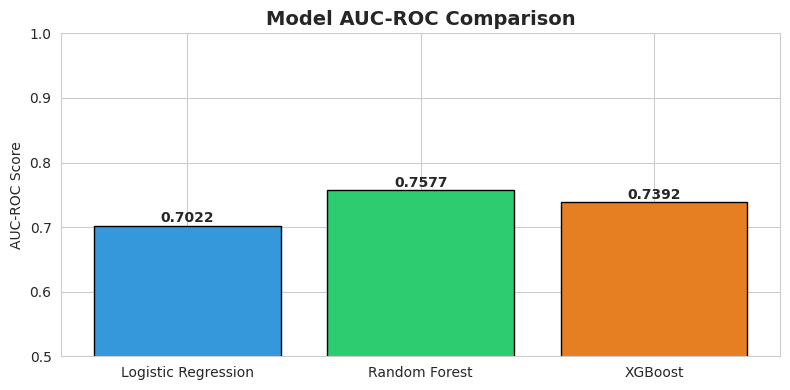

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                          random_state=42, n_jobs=-1)
}

results        = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    preds = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    results[name]        = auc
    trained_models[name] = model
    print(f'\n{name}')
    print(f'   AUC-ROC: {auc:.4f}')
    print(classification_report(y_test, preds, target_names=['Minor', 'Severe']))

best_name  = max(results, key=results.get)
best_model = trained_models[best_name]
print(f'\nBest Model: {best_name}  |  AUC = {results[best_name]:.4f}')

# Bar chart comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(results.keys(), results.values(),
               color=['#3498db', '#2ecc71', '#e67e22'], edgecolor='black')
plt.ylim(0.5, 1.0)
plt.title('Model AUC-ROC Comparison', fontsize=14, fontweight='bold')
plt.ylabel('AUC-ROC Score')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 10 - Model Evaluation

We evaluate the best model in detail using:

- ROC Curve: Shows the trade-off between true positive rate and false positive rate across all thresholds
- Confusion Matrix: Shows exact counts of correct and incorrect predictions

For accident severity prediction, high recall on the Severe class is more important than overall accuracy. Missing a severe accident is a more costly error than a false alarm.

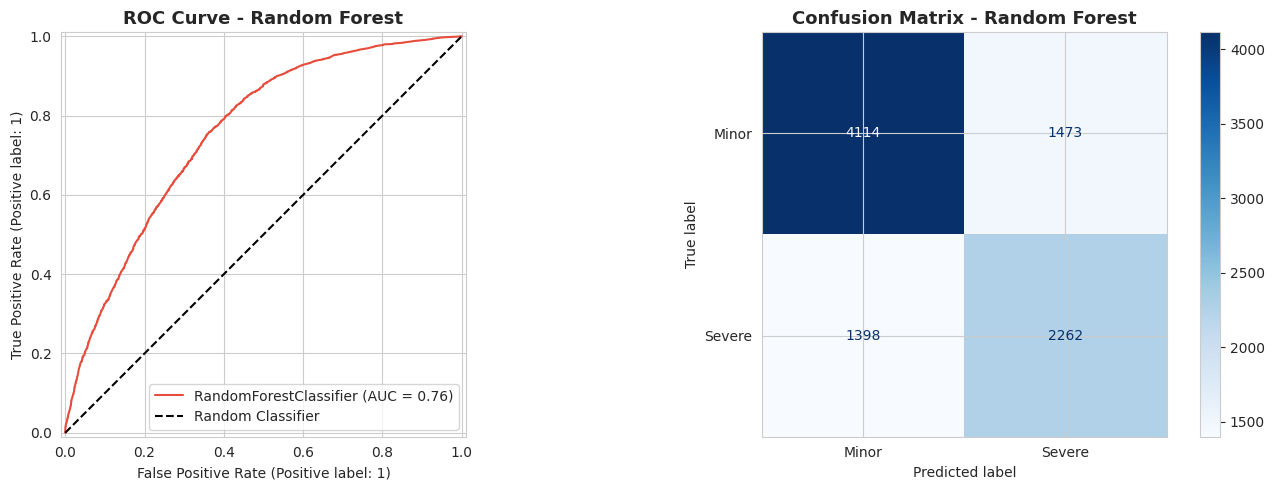


Sample Accident Prediction:
   Severity Probability : 15.00%
   Prediction           : MINOR


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_estimator(
    best_model, X_test_sc, y_test,
    ax=axes[0], color='#e74c3c'
)
axes[0].set_title(f'ROC Curve - {best_name}', fontsize=13, fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].legend()

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_sc, y_test,
    display_labels=['Minor', 'Severe'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix - {best_name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Sample prediction
sample    = X_test.iloc[[0]]
sample_sc = scaler.transform(sample)
prob      = best_model.predict_proba(sample_sc)[0][1]
label     = 'SEVERE' if prob >= 0.5 else 'MINOR'
print(f'\nSample Accident Prediction:')
print(f'   Severity Probability : {prob:.2%}')
print(f'   Prediction           : {label}')

## Phase 11 - SHAP Explainability

SHAP (SHapley Additive exPlanations) tells us why the model made each prediction by showing how much each pre-crash feature contributed to the severity prediction.

This is critical for real world accident prevention systems because:
- Traffic engineers need to know which conditions are most dangerous
- Autonomous vehicle systems need interpretable signals to act on
- Policy makers need to understand which road features to prioritize

Red dots mean high feature value. Blue dots mean low feature value. The x-axis shows how much each feature pushed the prediction toward severe or minor.

100%|===================| 3999/4000 [19:59<00:00]       

SHAP Summary Plot for Random Forest:


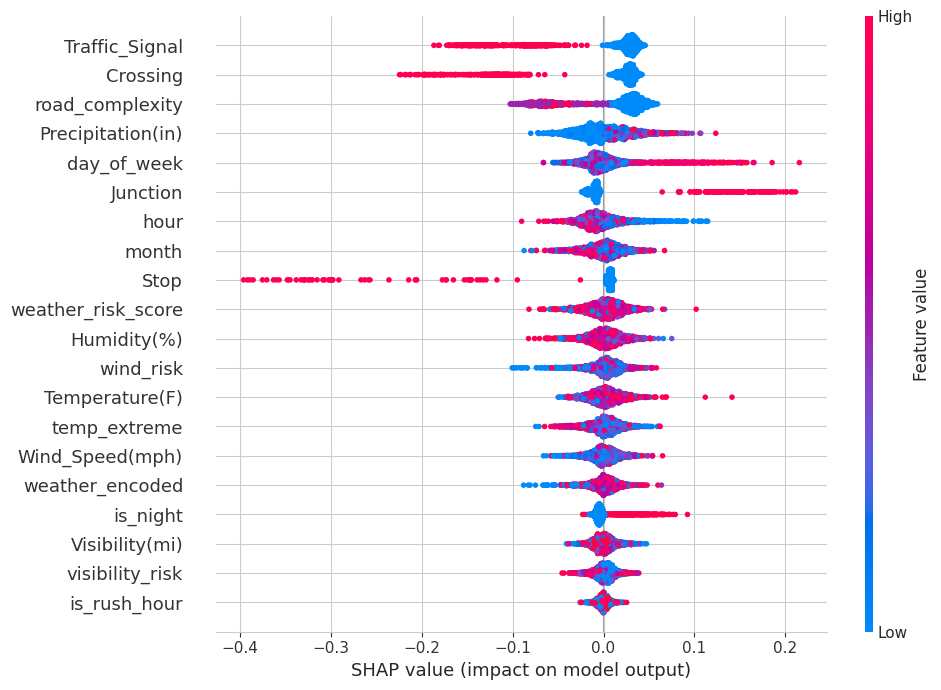


Top 10 Pre-Crash Signals Predicting Severe Accidents:
Traffic_Signal        0.043577
Crossing              0.041220
road_complexity       0.038925
Precipitation(in)     0.021739
day_of_week           0.020565
Junction              0.019199
hour                  0.016668
month                 0.014641
Stop                  0.014363
weather_risk_score    0.014338
dtype: float64


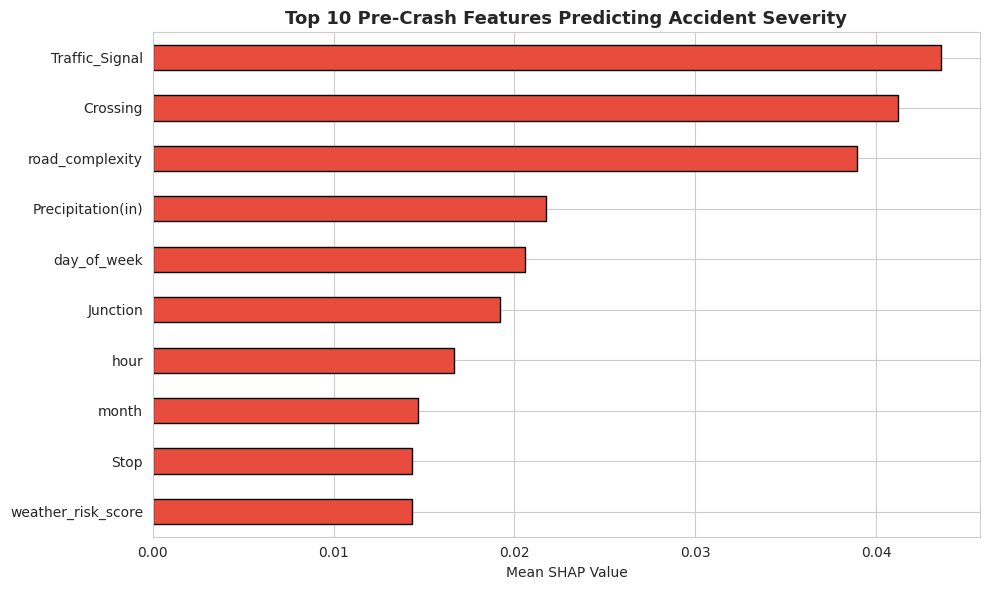

In [13]:
# Use a sample for SHAP to keep computation fast
shap_sample    = X_test_sc[:2000]
shap_sample_df = X_test.iloc[:2000]

explainer   = shap.Explainer(best_model, shap_sample)
shap_values = explainer(shap_sample, check_additivity=False)

# Handle both binary and multiclass SHAP output shapes
shap_vals = shap_values.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]  # class index 1 = Severe

print(f'SHAP Summary Plot for {best_name}:')
shap.summary_plot(
    shap_vals,
    features=shap_sample_df,
    feature_names=FEATURES_ALL,
    plot_size=(10, 7),
    show=True
)

# Top 10 most important pre-crash signals
mean_shap = np.abs(shap_vals).mean(axis=0)
feat_imp  = pd.Series(mean_shap, index=FEATURES_ALL).sort_values(ascending=False)
print('\nTop 10 Pre-Crash Signals Predicting Severe Accidents:')
print(feat_imp.head(10))

# Feature importance bar chart
plt.figure(figsize=(10, 6))
feat_imp.head(10).sort_values().plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Top 10 Pre-Crash Features Predicting Accident Severity', fontsize=13, fontweight='bold')
plt.xlabel('Mean SHAP Value')
plt.tight_layout()
plt.show()

## Phase 12 - Save Model Artifacts

We save the trained model and scaler so the prediction system can be used in the future without retraining.

- best_model.pkl: Trained ML model
- scaler.pkl: Feature scaler
- feature_list.pkl: List of feature names
- weather_encoder.pkl: Weather condition encoder

In [14]:
os.makedirs('models', exist_ok=True)

with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/feature_list.pkl', 'wb') as f:
    pickle.dump(FEATURES_ALL, f)

with open('models/weather_encoder.pkl', 'wb') as f:
    pickle.dump(weather_encoder, f)

print('All model artifacts saved.')
print(f'\nFinal Model Summary:')
print(f'   Best Model : {best_name}')
print(f'   AUC-ROC    : {results[best_name]:.4f}')
print(f'   Features   : {len(FEATURES_ALL)}')
print(f'   Training samples (after SMOTE): {X_train_bal.shape[0]:,}')
print(f'   Test samples                  : {X_test_sc.shape[0]:,}')

All model artifacts saved.

Final Model Summary:
   Best Model : Random Forest
   AUC-ROC    : 0.7577
   Features   : 21
   Training samples (after SMOTE): 44,698
   Test samples                  : 9,247
